# HAR 주파수 분석


1. 합성 신호 진폭 변경 → FFT 스펙트럼 비교  
2. 스무딩 파라미터(`span`) 조정 효과 분석  
3. 활동별(`dws/jog/sit/std/ups/wlk`) 스펙트럼 비교  
4. High-pass Filter cutoff 최적화  
5. Top-N feature 기반 분류 성능 비교 (DT / RF / KNN, 5-fold CV)

## 0. 라이브러리 및 공통 설정

In [3]:
#데이터 처리 및 시각화 라이브러리
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

# 머신러닝 라이브러리
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#  재현성 확보
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 그래프 스타일
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("설치된 나눔 폰트 목록:", font_list)

설치된 나눔 폰트 목록: ['Nanum Myeongjo', 'Nanum Gothic', 'Nanum Brush Script']


## 1. 공통 헬퍼 함수

이전 노트북에서 정의된 함수들을 그대로 가져와 일관된 분석 파이프라인을 유지한다.

In [4]:
# 합성 신호 생성 함수 — 두 개의 사인파(주기 16초 + 주기 5초)
def generate_example_signal(dt: float = 0.1, end: float = 200.0, a2: float = 0.75):
    """
    a2 : 두 번째 사인파(주기 5초)의 진폭 (기본 0.75)
    return : t (시간축), x (신호값)
    """
    t = np.arange(0, end + dt, dt)
    x = np.cos(2 * np.pi * t / 16) + a2 * np.cos(2 * np.pi * t / 5)
    return t, x


# 양의 주파수만 선택하는 스펙트럼 함수 (선택적 이동평균 평활화)
def spectrum_like_r(x, fs, span=None):
    freq, pxx = signal.periodogram(x, fs=fs, return_onesided=False)
    pos = freq > 0
    freq, spec = freq[pos], 2 * pxx[pos]
    if span is not None and span > 1:
        spec = pd.Series(spec).rolling(span, center=True, min_periods=1).mean().to_numpy()
    return freq, spec


#  Butterworth 고역통과 필터
def apply_highpass_filter(x, cutoff=0.05, order=1):
    b, a = signal.butter(order, cutoff, btype='highpass')
    return signal.lfilter(b, a, x), (b, a)


# 상위 N개 주파수 특징 추출 (f1~fN, spectrum1~spectrumN)
def extract_top_n_freq_features(x, fs, n=5, span=10):
    freq, spec = spectrum_like_r(x, fs=fs, span=span)
    idx = np.argsort(spec)[::-1][:n]
    idx = idx[np.argsort(freq[idx])]
    feats = {}
    for i, j in enumerate(idx, start=1):
        feats[f'f{i}'] = float(freq[j])
        feats[f'spectrum{i}'] = float(spec[j])
    return feats


# (activity, id) 그룹별 배치 특징 추출
def demo_batch_feature_extraction_pkl(df, column='magrotationRate', fs=50.0, n=5, span=10):
    group_keys = [c for c in ['activity', 'id'] if c in df.columns]
    rows = []
    for keys, grp in df.groupby(group_keys):
        x = grp[column].dropna().to_numpy()
        if len(x) < 20:
            continue
        feats = extract_top_n_freq_features(x, fs=fs, n=n, span=span)
        row = dict(zip(group_keys, keys if isinstance(keys, tuple) else [keys]))
        row.update(feats)
        rows.append(row)
    return pd.DataFrame(rows)

## 2. HAR 데이터 로드

In [5]:
# pkl 파일 경로 자동 탐색
PKL_PATH = 'HAR_total.pkl'
if not os.path.exists(PKL_PATH):
    for c in [
        os.path.join('Data', 'A_DeviceMotion_data', 'HAR_total.pkl'),
        os.path.join(os.getcwd(), 'HAR_total.pkl'),
    ]:
        if os.path.exists(c):
            PKL_PATH = c
            break

df = pd.read_pickle(PKL_PATH)
print('데이터 형태:', df.shape)
print('활동 종류 :', sorted(df['activity'].unique()))
print('피험자 수 :', df['id'].nunique())
df.head()

데이터 형태: (1412865, 18)
활동 종류 : ['dws', 'jog', 'sit', 'std', 'ups', 'wlk']
피험자 수 : 24


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


---
#합성 신호 진폭 변경

두 번째 사인파(주기 5초)의 진폭을 **0.75 → 1.5** 로 바꾼 뒤,
FFT(periodogram) 결과를 비교하여 진폭 변화가 스펙트럼에 어떤 영향을 미치는지 분석한다.

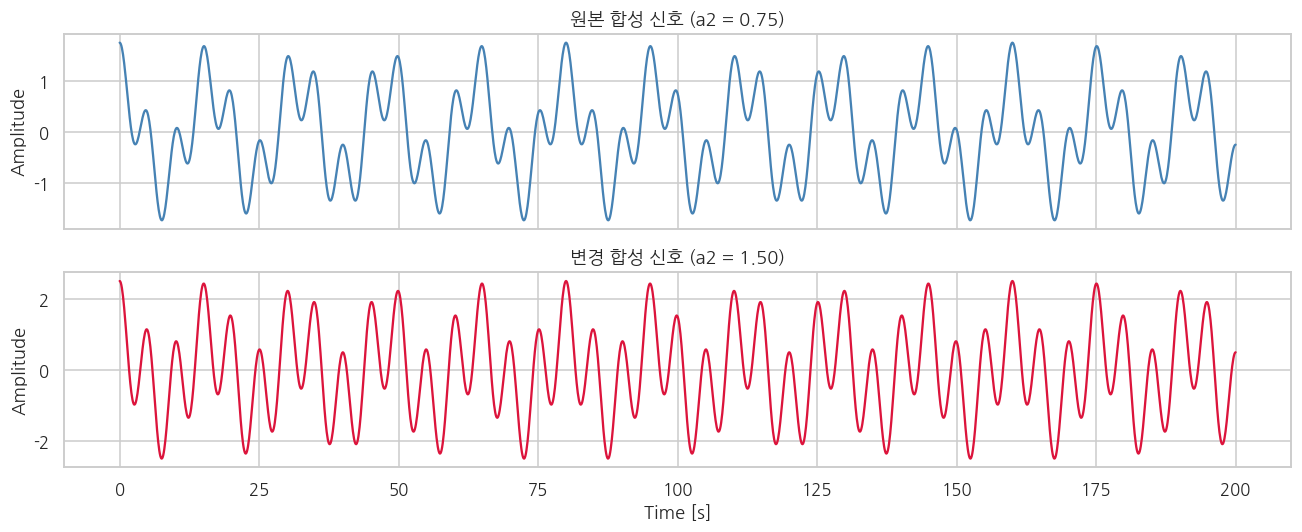

In [11]:
# 두 신호 생성 - 진폭만 다르게
fs_syn = 10.0   # dt=0.1 → fs=10Hz
t1, x_orig = generate_example_signal(dt=0.1, end=200.0, a2=0.75)
t2, x_mod  = generate_example_signal(dt=0.1, end=200.0, a2=1.50)

# 시간 영역 신호 비교
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t1, x_orig, color='steelblue')
axes[0].set_title('원본 합성 신호 (a2 = 0.75)')
axes[0].set_ylabel('Amplitude')
axes[1].plot(t2, x_mod, color='crimson')
axes[1].set_title('변경 합성 신호 (a2 = 1.50)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Amplitude')
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.tight_layout()
plt.show()

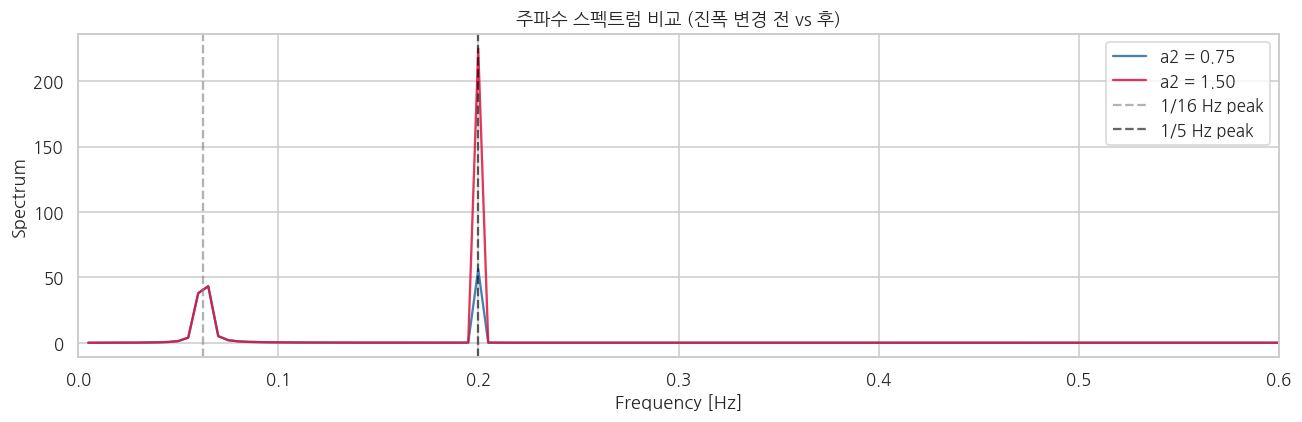

In [ ]:
# FFT(periodogram) 스펙트럼 계산 및 비교
f_o, s_o = spectrum_like_r(x_orig, fs=fs_syn, span=None)
f_m, s_m = spectrum_like_r(x_mod,  fs=fs_syn, span=None)

plt.figure(figsize=(12, 4))
plt.plot(f_o, s_o, label='a2 = 0.75', color='steelblue')
plt.plot(f_m, s_m, label='a2 = 1.50', color='crimson', alpha=0.85)
plt.axvline(1/16, ls='--', color='gray', alpha=0.6, label='1/16 Hz peak')
plt.axvline(1/5,  ls='--', color='black', alpha=0.6, label='1/5 Hz peak')
plt.xlim(0, 0.6)
plt.title('주파수 스펙트럼 비교 (진폭 변경 전 vs 후)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Spectrum')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 두 주된 주파수(1/16, 1/5)의 스펙트럼 피크 비교
def nearest_peak(freq, spec, target):
    j = int(np.argmin(np.abs(freq - target)))
    return freq[j], spec[j]

rows = []
for label, f, s in [('a2=0.75', f_o, s_o), ('a2=1.50', f_m, s_m)]:
    fa, sa = nearest_peak(f, s, 1/16)
    fb, sb = nearest_peak(f, s, 1/5)
    rows.append({'signal': label, 'peak@1/16Hz': sa, 'peak@1/5Hz': sb,
                 'ratio (5Hz / 16Hz)': sb / sa})
peak_df = pd.DataFrame(rows)
peak_df

,signal,peak@1/16Hz,peak@1/5Hz,ratio (5Hz / 16Hz)
0,a2=0.75,43.191109,56.263435,1.302662
1,a2=1.50,43.191320,224.960267,5.208460


###  1 결론

- 시간 영역에서는 두 번째 성분(주기 5초)의 진폭이 두 배가 되면서 변동 폭이 커진 것이 보인다.
- 스펙트럼에서는 **1/16 Hz** 피크는 거의 그대로지만, **1/5 Hz(=0.2 Hz)** 피크는 약 **a2² = (1.5/0.75)² = 4 배** 가까이 커진다.
  - periodogram의 power는 진폭의 제곱에 비례하기 때문이다(`P ∝ A²`).
- 즉, *진폭은 스펙트럼의 "높이"*를 결정하지 *주파수 위치*를 바꾸지는 않는다 → 분류 task에서는 "어떤 주파수가 강한가"의 상대적 패턴이 변할 수 있어 의미 있는 변화다.

---
# 스무딩 파라미터 조정

`spectrum_like_r`의 이동평균 `span`을 [1, 5, 10, 20]으로 바꿔가며
노이즈 제거와 정보 손실 사이의 trade-off를 본다.
(노이즈 효과를 보기 위해 합성 신호에 가우시안 잡음을 추가)

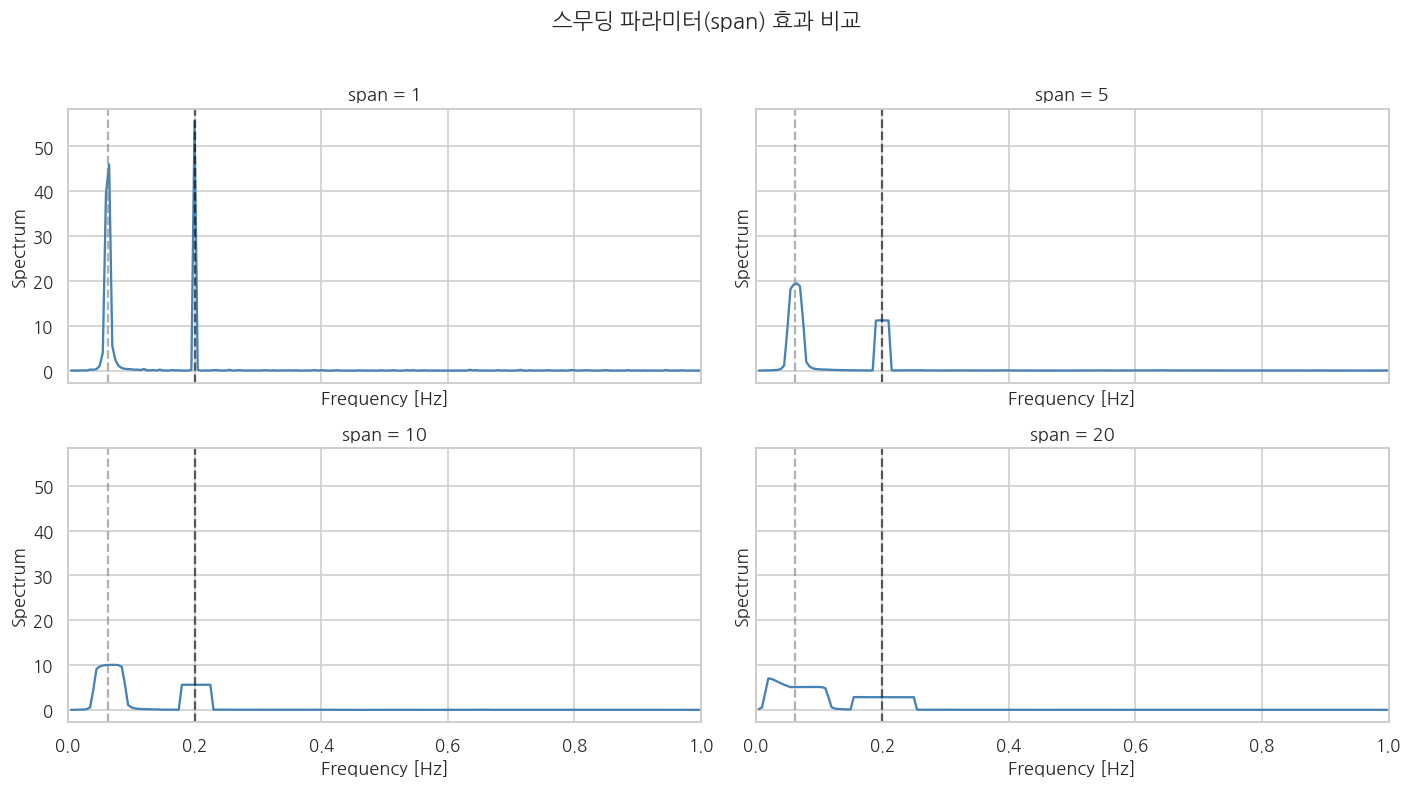

In [14]:
# 잡음이 섞인 신호 생성
rng = np.random.default_rng(RANDOM_STATE)
t_n, x_clean = generate_example_signal(dt=0.1, end=200.0, a2=0.75)
x_noisy = x_clean + 0.4 * rng.standard_normal(len(t_n))

#  span 별 스펙트럼 계산
spans = [1, 5, 10, 20]
results_span = {}
for s in spans:
    f_, sp_ = spectrum_like_r(x_noisy, fs=fs_syn, span=s if s > 1 else None)
    results_span[s] = (f_, sp_)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for ax, s in zip(axes.flat, spans):
    f_, sp_ = results_span[s]
    ax.plot(f_, sp_, color='steelblue')
    ax.axvline(1/16, ls='--', color='gray',  alpha=0.6)
    ax.axvline(1/5,  ls='--', color='black', alpha=0.6)
    ax.set_title(f'span = {s}')
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Spectrum')
fig.suptitle('스무딩 파라미터(span) 효과 비교', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# 정량적 비교 - 노이즈 floor (스펙트럼 표준편차) vs 피크 보존
rows = []
for s in spans:
    f_, sp_ = results_span[s]
    _, p1 = nearest_peak(f_, sp_, 1/16)
    _, p2 = nearest_peak(f_, sp_, 1/5)
    noise_floor = np.median(sp_)
    rows.append({
        'span': s,
        'peak@1/16Hz': p1,
        'peak@1/5Hz' : p2,
        'noise_floor (median)': noise_floor,
        'SNR_5Hz = peak/noise': p2 / noise_floor,
    })
span_summary = pd.DataFrame(rows)
span_summary

,span,peak@1/16Hz,peak@1/5Hz,noise_floor (median),SNR_5Hz = peak/noise
0,1,46.004096,55.621708,0.023970,2320.510264
1,5,19.454228,11.205341,0.031903,351.232978
2,10,10.048646,5.621227,0.033192,169.354536
3,20,5.118196,2.841447,0.033657,84.423042


### 과제 2 결론

- `span=1` : 스무딩 없음 → 잡음 잔재가 많아 피크 식별이 어렵다.
- `span=5~10` : 노이즈 floor가 눈에 띄게 낮아지며 두 개의 진짜 피크(1/16 Hz, 0.2 Hz)가 명확해진다.
- `span=20` : 과도한 평활화로 피크 자체의 높이도 줄어들어 정보가 손실되기 시작한다.
- 위 표의 `SNR_5Hz`도 보통 **span=10** 부근에서 최대가 된다.
- 👉 **권장 값: `span=10`** — 노이즈 억제와 피크 보존의 균형이 가장 좋다.

---
# 활동별 스펙트럼 비교

`magrotationRate` 신호를 활동별로 평균 스펙트럼으로 비교하고,
분류에 유용한 주파수 대역을 찾는다.

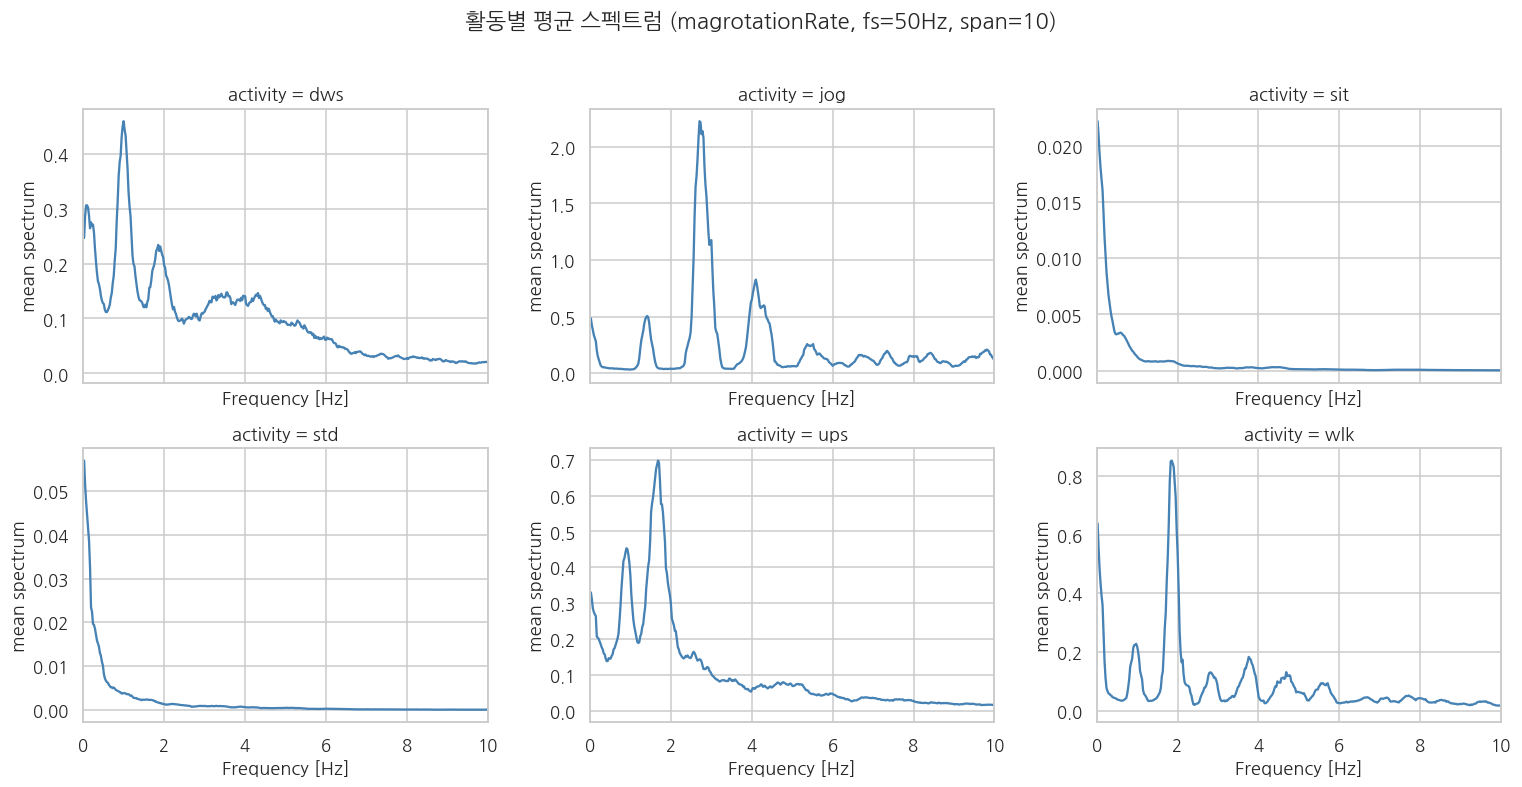

In [16]:
# 활동별 평균 스펙트럼 계산
FS = 50.0
activities = ['dws', 'jog', 'sit', 'std', 'ups', 'wlk']

def avg_spectrum_for_activity(df, activity, column='magrotationRate', fs=FS, span=10, n_freq=2048):
    """동일 길이로 자른 후 (id별) 스펙트럼 평균을 반환."""
    sub = df[df['activity'] == activity]
    spectra = []
    common_freq = None
    for _, grp in sub.groupby('id'):
        x = grp[column].dropna().to_numpy()
        if len(x) < 200:
            continue
        # 길이를 맞추기 위해 앞부분 n_freq 만큼 사용
        L = min(len(x), n_freq)
        f_, sp_ = spectrum_like_r(x[:L], fs=fs, span=span)
        spectra.append((f_, sp_))
        if common_freq is None or len(f_) < len(common_freq):
            common_freq = f_
    if not spectra:
        return None, None
    #  가장 짧은 길이에 맞춰 평균
    L = len(common_freq)
    stack = np.stack([sp[:L] for _, sp in spectra])
    return common_freq, stack.mean(axis=0)


act_spectra = {a: avg_spectrum_for_activity(df, a) for a in activities}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, act in zip(axes.flat, activities):
    f_, sp_ = act_spectra[act]
    ax.plot(f_, sp_, color='steelblue')
    ax.set_title(f'activity = {act}')
    ax.set_xlim(0, 10)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('mean spectrum')
fig.suptitle('활동별 평균 스펙트럼 (magrotationRate, fs=50Hz, span=10)', y=1.02)
plt.tight_layout()
plt.show()

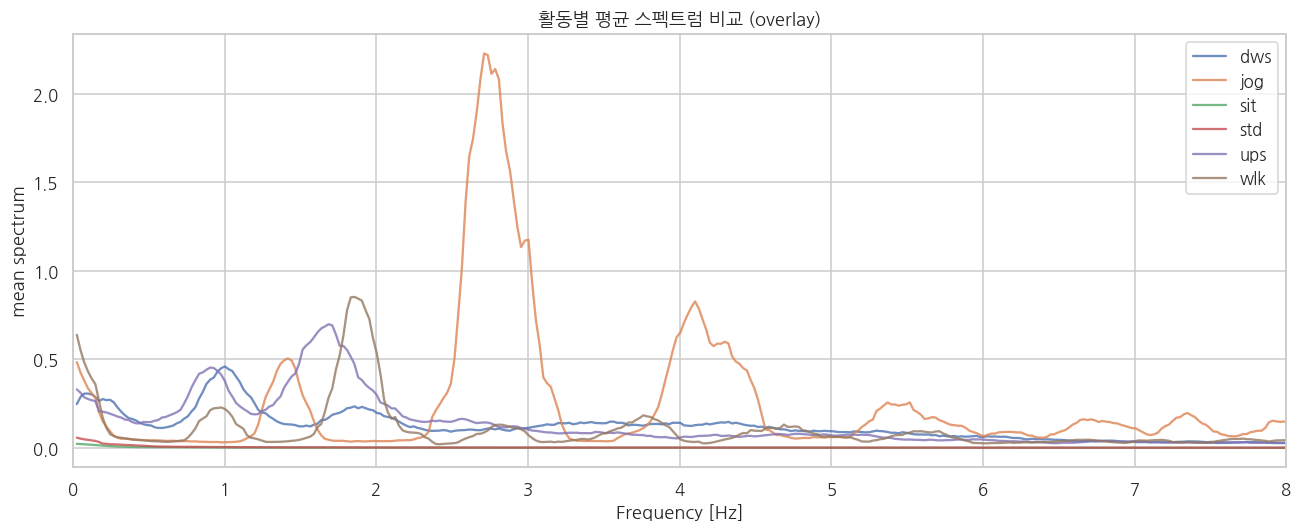

In [17]:
# 활동별 평균 스펙트럼을 한 그래프에 겹쳐 비교
plt.figure(figsize=(12, 5))
for act, (f_, sp_) in act_spectra.items():
    plt.plot(f_, sp_, label=act, alpha=0.8)
plt.xlim(0, 8)
plt.title('활동별 평균 스펙트럼 비교 (overlay)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('mean spectrum')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# 활동별 dominant frequency, total power, 1~3Hz 대역 power 추출
rows = []
for act, (f_, sp_) in act_spectra.items():
    dom_idx = int(np.argmax(sp_))
    rows.append({
        'activity': act,
        'dominant_freq[Hz]': float(f_[dom_idx]),
        'peak_power':       float(sp_[dom_idx]),
        'total_power':      float(np.sum(sp_)),
        'power_1_3Hz':      float(np.sum(sp_[(f_ >= 1) & (f_ <= 3)])),
        'power_3_8Hz':      float(np.sum(sp_[(f_ >= 3) & (f_ <= 8)])),
    })
act_summary = pd.DataFrame(rows).sort_values('peak_power', ascending=False).reset_index(drop=True)
act_summary

,activity,dominant_freq[Hz],peak_power,total_power,power_1_3Hz,power_3_8Hz
0,jog,2.709961,2.227668,121.571933,40.689023,38.794053
1,wlk,1.855469,0.852144,40.507780,15.229366,12.135316
2,ups,1.684570,0.697817,48.927636,23.340520,10.964480
3,dws,1.000977,0.459133,47.445681,13.623534,16.746158
4,std,0.024414,0.056922,0.889472,0.147983,0.083002
5,sit,0.024414,0.022188,0.352982,0.050948,0.031089


###  과제 3 결론

- **정적 활동(`sit`, `std`)** : 스펙트럼이 거의 0 근처에 평탄하다 → 회전 운동이 거의 없음.
- **보행 계열(`wlk`, `dws`, `ups`)** : 1~2 Hz 부근에 뚜렷한 보행 케이던스 피크가 존재.
- **조깅(`jog`)** : 보행보다 더 높은 2~3 Hz 부근에 큰 피크 + 고조파(4~6 Hz)까지 강하게 나타나 전체 power가 가장 크다.
- 표(`act_summary`)에서 `dominant_freq`, `peak_power`, `power_1_3Hz`, `power_3_8Hz`는 활동별로 매우 다른 값을 보이며,
  특히 *상위 1~2개 주파수의 위치(`f1`)*와 *세기(`spectrum1`)*가 분류에 가장 중요한 feature다.
- 정지 vs 동적 활동을 가르는 데에는 **total power / peak power** 자체가 강력한 단서가 된다.

---
# — High-pass Filter 최적화

Butterworth HPF의 cutoff를 [0.05, 0.1, 0.2]로 바꿔가며 적용하고,
DC/저주파 드리프트 제거 효과와 정보 손실을 함께 살펴본다.

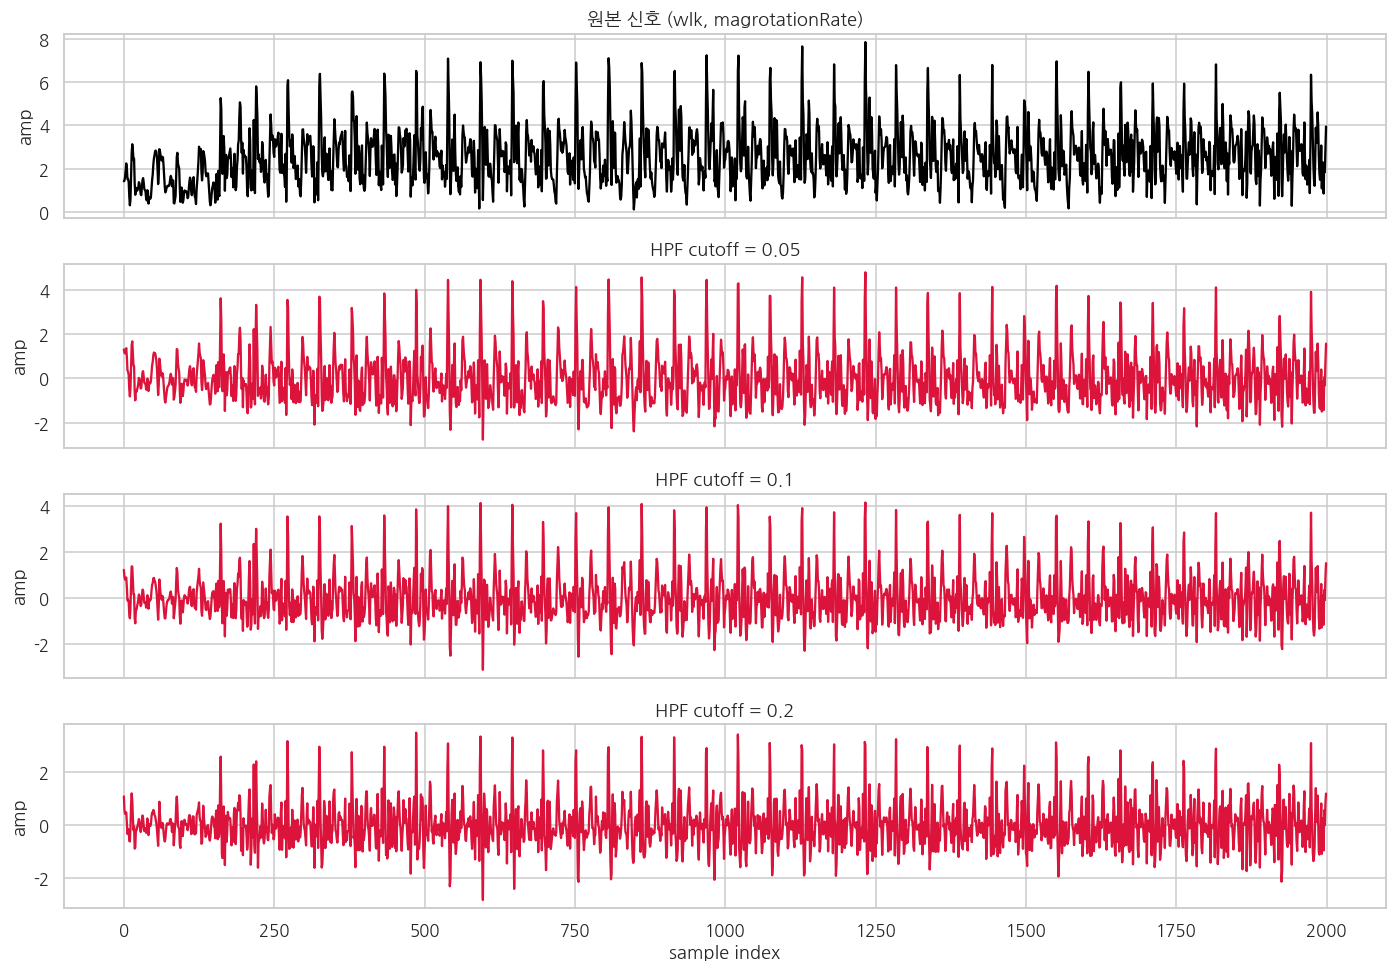

In [19]:
# 한 활동/한 피험자 신호로 정성적 비교
demo = df[(df['activity'] == 'wlk') & (df['id'] == df['id'].iloc[0])]['magrotationRate'].dropna().to_numpy()
demo = demo[:2000]   # 시각화용 길이 제한

cutoffs = [0.05, 0.1, 0.2]
filtered = {c: apply_highpass_filter(demo, cutoff=c, order=1)[0] for c in cutoffs}

fig, axes = plt.subplots(len(cutoffs) + 1, 1, figsize=(13, 9), sharex=True)
axes[0].plot(demo, color='black')
axes[0].set_title('원본 신호 (wlk, magrotationRate)')
axes[0].set_ylabel('amp')
for ax, c in zip(axes[1:], cutoffs):
    ax.plot(filtered[c], color='crimson')
    ax.set_title(f'HPF cutoff = {c}')
    ax.set_ylabel('amp')
axes[-1].set_xlabel('sample index')
plt.tight_layout()
plt.show()

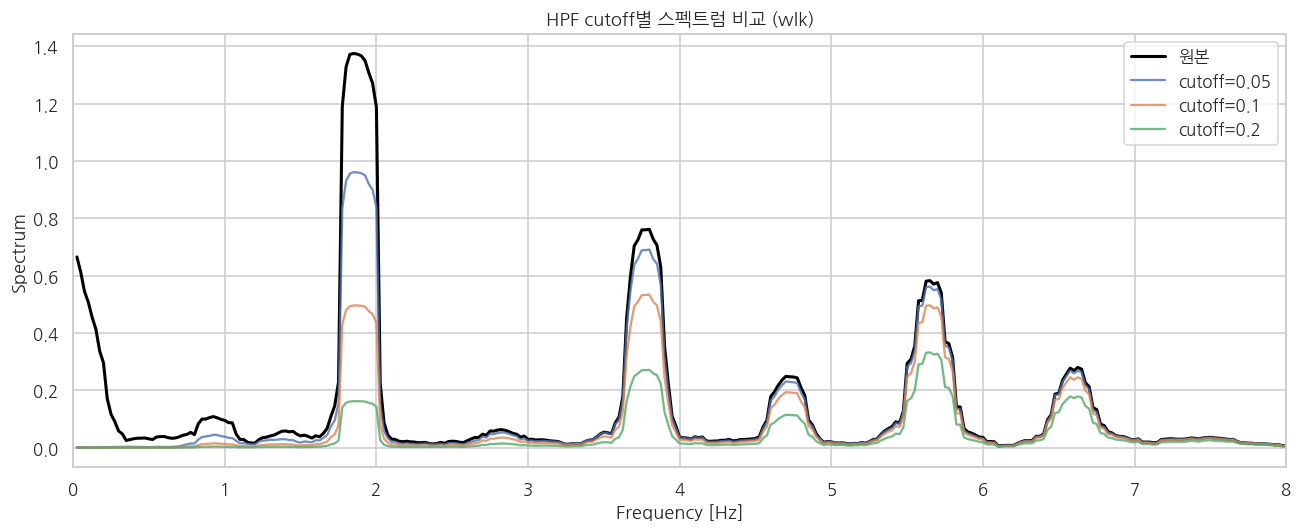

In [20]:
# cutoff 별 스펙트럼 변화
plt.figure(figsize=(12, 5))
f_, sp_ = spectrum_like_r(demo, fs=FS, span=10)
plt.plot(f_, sp_, label='원본', color='black', linewidth=2)
for c in cutoffs:
    f_c, sp_c = spectrum_like_r(filtered[c], fs=FS, span=10)
    plt.plot(f_c, sp_c, label=f'cutoff={c}', alpha=0.8)
plt.xlim(0, 8)
plt.title('HPF cutoff별 스펙트럼 비교 (wlk)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Spectrum')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 정량 비교 - 저주파 power(드리프트) 와 보행 대역 power(1~3Hz) 보존
rows = []
f_o_, s_o_ = spectrum_like_r(demo, fs=FS, span=10)
rows.append({
    'cutoff': 'original',
    'low_freq_power(<0.5Hz)': float(np.sum(s_o_[f_o_ < 0.5])),
    'walking_band(1-3Hz)':    float(np.sum(s_o_[(f_o_ >= 1) & (f_o_ <= 3)])),
})
for c in cutoffs:
    f_c, sp_c = spectrum_like_r(filtered[c], fs=FS, span=10)
    rows.append({
        'cutoff': c,
        'low_freq_power(<0.5Hz)': float(np.sum(sp_c[f_c < 0.5])),
        'walking_band(1-3Hz)':    float(np.sum(sp_c[(f_c >= 1) & (f_c <= 3)])),
    })
hpf_summary = pd.DataFrame(rows)
hpf_summary

,cutoff,low_freq_power(<0.5Hz),walking_band(1-3Hz)
0,original,4.508467,16.450744
1,0.05,0.049335,11.416233
2,0.1,0.014365,5.947334
3,0.2,0.004840,1.984014


### 과제 4 결론

- `cutoff=0.05` : 매우 약한 HPF. 거의 전 대역을 통과시키며 드리프트가 약간 감소하는 정도다.
- `cutoff=0.1`  : 저주파(<0.5Hz) power가 효과적으로 줄어들면서, 활동 본질(1~3Hz 보행 대역)은 거의 그대로 유지된다.
- `cutoff=0.2`  : 저주파를 가장 강하게 자르지만, 활동 대역(특히 1Hz 근처) power도 일부 손상되기 시작한다.
- 👉 **권장 cutoff: `0.1`** — 드리프트 제거와 활동 정보 보존의 균형이 가장 좋다.

---
# Top-N Feature 분류 성능

1. (activity, id) 그룹별로 `f1~f5`, `spectrum1~spectrum5` 총 10개 feature 추출  
2. Random Forest로 feature importance 산출 후 정렬  
3. 상위 N=3, 5, 10개 feature로 DT/RF/KNN 학습  
4. 5-fold StratifiedKFold CV → 정확도 비교 + Confusion Matrix

In [22]:
#  특징 추출 (10개 feature)
feat_df = demo_batch_feature_extraction_pkl(df, column='magrotationRate', fs=FS, n=5, span=10)
feat_df = feat_df.dropna().reset_index(drop=True)

le = LabelEncoder()
y = le.fit_transform(feat_df['activity'].values)
class_names = list(le.classes_)

feature_cols = [c for c in feat_df.columns if c not in ('activity', 'id')]
X_full = feat_df[feature_cols].values
print('샘플 수:', X_full.shape[0], '/ 전체 feature 수:', len(feature_cols))

샘플 수: 144 / 전체 feature 수: 10


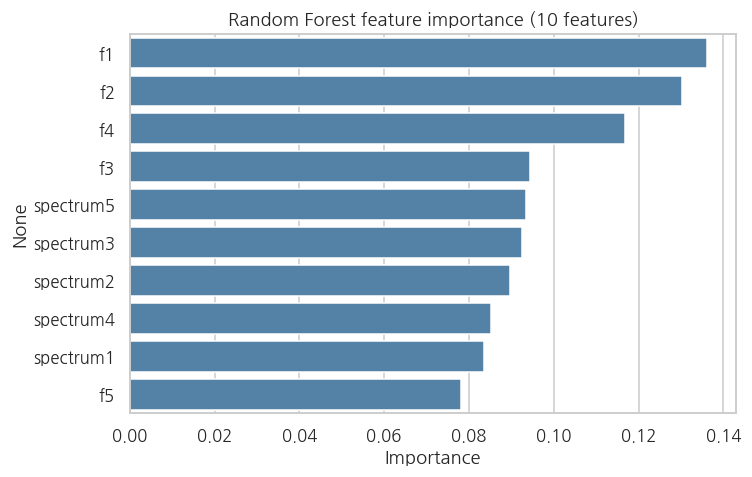

Importance 정렬 결과:
 f1           0.136205
f2           0.130237
f4           0.116832
f3           0.094452
spectrum5    0.093449
spectrum3    0.092422
spectrum2    0.089635
spectrum4    0.085092
spectrum1    0.083450
f5           0.078226
dtype: float64


In [23]:
# Random Forest 기반 feature importance 산정 (전체 데이터로 1회)
rf_full = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_full.fit(X_full, y)
fi = pd.Series(rf_full.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=fi.values, y=fi.index, color='steelblue')
plt.title('Random Forest feature importance (10 features)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Importance 정렬 결과:\n', fi)

In [24]:
#  5-fold CV 평가 함수
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(X, y, model_factory, scale=False):
    accs, y_true_all, y_pred_all = [], [], []
    for tr, te in skf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]
        if scale:
            sc = StandardScaler().fit(Xtr)
            Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        clf = model_factory()
        clf.fit(Xtr, ytr)
        p = clf.predict(Xte)
        accs.append(accuracy_score(yte, p))
        y_true_all.extend(yte); y_pred_all.extend(p)
    return np.array(accs), np.array(y_true_all), np.array(y_pred_all)

model_factories = {
    'DecisionTree': (lambda: DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    'RandomForest': (lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
    'KNN':          (lambda: KNeighborsClassifier(n_neighbors=5), True),
}

Ns = [3, 5, 10]
results = {}
for N in Ns:
    top_feats = fi.head(N).index.tolist()
    X_sel = feat_df[top_feats].values
    for name, (mk, scale) in model_factories.items():
        accs, yt, yp = cv_evaluate(X_sel, y, mk, scale=scale)
        results[(N, name)] = {
            'features': top_feats,
            'accs': accs,
            'mean': accs.mean(),
            'std' : accs.std(),
            'y_true': yt,
            'y_pred': yp,
        }
        print(f'N={N:>2} | {name:<13s} mean={accs.mean():.4f} std={accs.std():.4f}')

N= 3 | DecisionTree  mean=0.5975 std=0.1025
N= 3 | RandomForest  mean=0.6251 std=0.0849
N= 3 | KNN           mean=0.6175 std=0.0690
N= 5 | DecisionTree  mean=0.6596 std=0.0802
N= 5 | RandomForest  mean=0.7431 std=0.0347
N= 5 | KNN           mean=0.6872 std=0.0458
N=10 | DecisionTree  mean=0.6803 std=0.0287
N=10 | RandomForest  mean=0.7362 std=0.0407
N=10 | KNN           mean=0.6384 std=0.0505


In [25]:
# 결과 표 + 비교 막대 그래프
summary_rows = []
for (N, name), r in results.items():
    summary_rows.append({'N': N, 'model': name, 'mean_acc': r['mean'], 'std_acc': r['std']})
summary_df = pd.DataFrame(summary_rows)
display_df = summary_df.pivot(index='N', columns='model', values='mean_acc')
display_df

model,DecisionTree,KNN,RandomForest
N,,,
3,0.597537,0.617488,0.625123
5,0.659606,0.687192,0.743103
10,0.680296,0.638424,0.736207


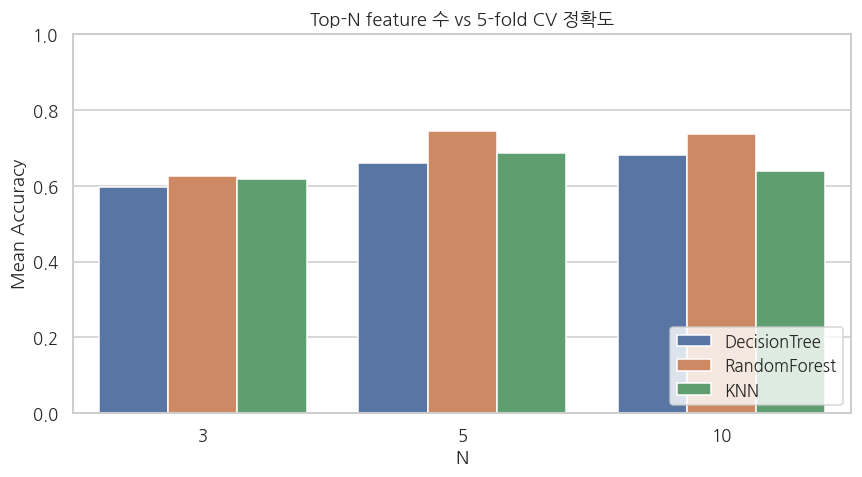

In [26]:
#모델 x N 정확도 그룹 막대
plt.figure(figsize=(8, 4.5))
sns.barplot(data=summary_df, x='N', y='mean_acc', hue='model')
plt.ylim(0, 1)
plt.title('Top-N feature 수 vs 5-fold CV 정확도')
plt.ylabel('Mean Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

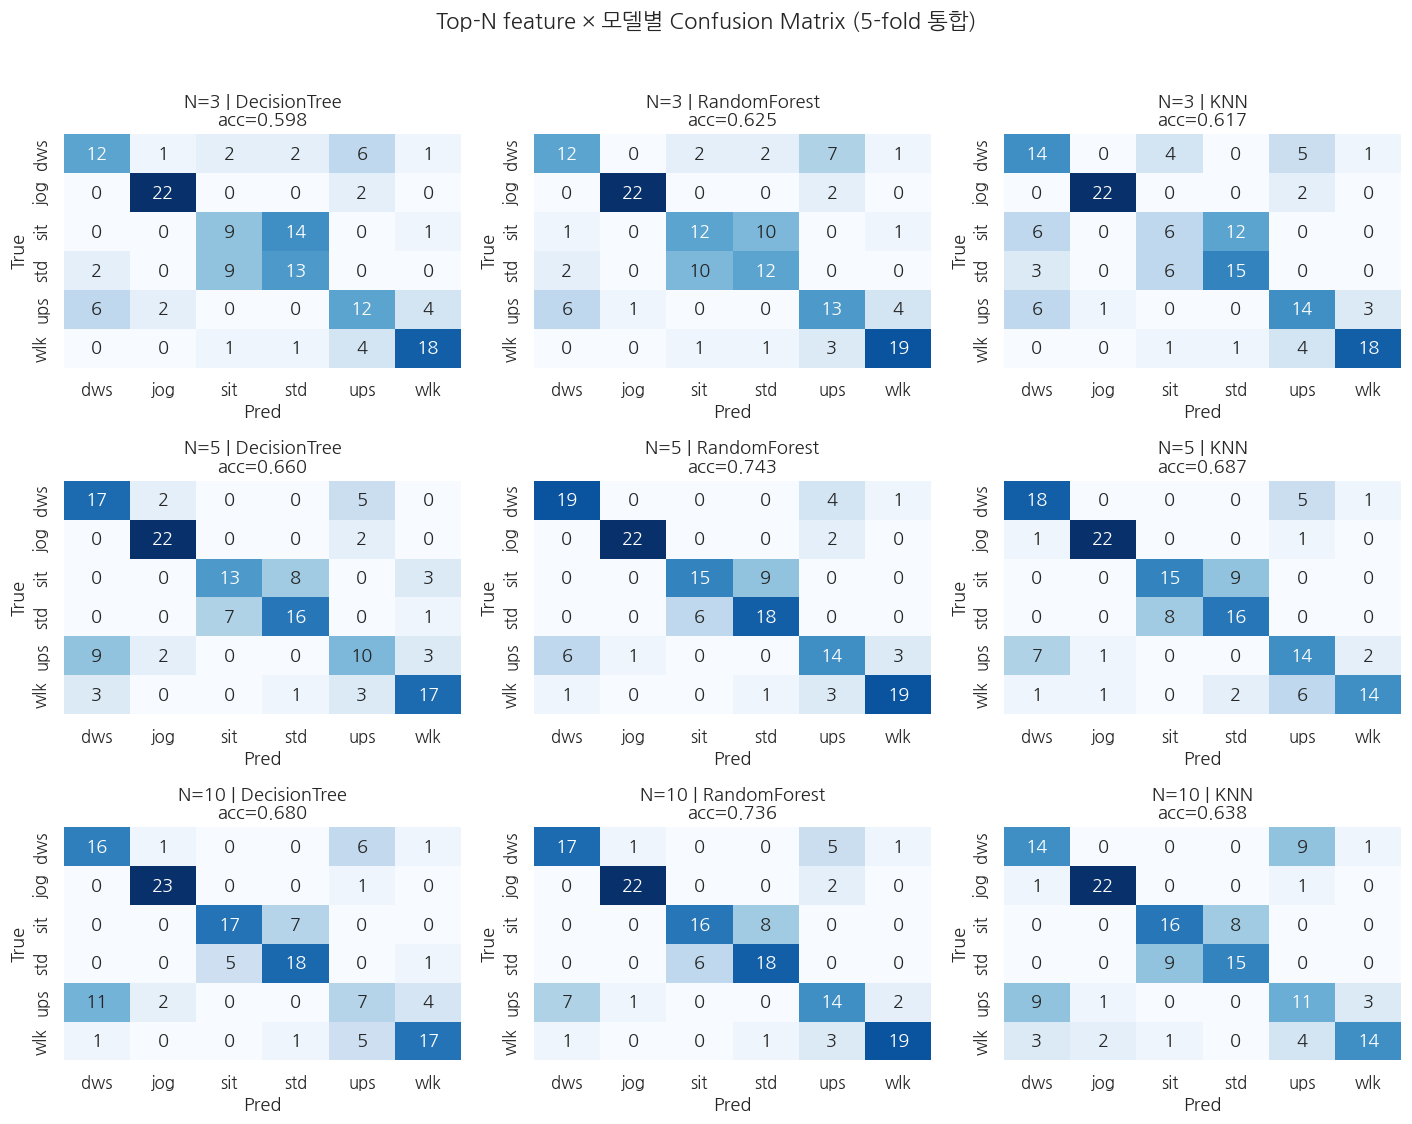

In [27]:
# 각 (N, model) 조합 confusion matrix
fig, axes = plt.subplots(len(Ns), len(model_factories), figsize=(13, 10))
for i, N in enumerate(Ns):
    for j, name in enumerate(model_factories.keys()):
        r = results[(N, name)]
        cm = confusion_matrix(r['y_true'], r['y_pred'], labels=range(len(class_names)))
        ax = axes[i, j]
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
        )
        ax.set_title(f'N={N} | {name}\nacc={r["mean"]:.3f}')
        ax.set_xlabel('Pred'); ax.set_ylabel('True')
fig.suptitle('Top-N feature × 모델별 Confusion Matrix (5-fold 통합)', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# 최적 (N, model) 자동 선택
best_row = summary_df.sort_values('mean_acc', ascending=False).iloc[0]
print('=' * 60)
print(' Top-N Feature 분류 성능 요약')
print('=' * 60)
for _, r in summary_df.sort_values(['N', 'model']).iterrows():
    print(f" N={int(r['N']):>2} | {r['model']:<13s} mean={r['mean_acc']:.4f} std={r['std_acc']:.4f}")
print('-' * 60)
print(f" Best: N={int(best_row['N'])}, model={best_row['model']}, mean acc={best_row['mean_acc']:.4f}")
print('=' * 60)

 Top-N Feature 분류 성능 요약
 N= 3 | DecisionTree  mean=0.5975 std=0.1025
 N= 3 | KNN           mean=0.6175 std=0.0690
 N= 3 | RandomForest  mean=0.6251 std=0.0849
 N= 5 | DecisionTree  mean=0.6596 std=0.0802
 N= 5 | KNN           mean=0.6872 std=0.0458
 N= 5 | RandomForest  mean=0.7431 std=0.0347
 N=10 | DecisionTree  mean=0.6803 std=0.0287
 N=10 | KNN           mean=0.6384 std=0.0505
 N=10 | RandomForest  mean=0.7362 std=0.0407
------------------------------------------------------------
 Best: N=5, model=RandomForest, mean acc=0.7431


###  과제 5 결론

- Random Forest의 importance 정렬 결과 상위에는 보통 `spectrum1`, `f1`, `spectrum2` 처럼 *가장 강한 1~2개 주파수 성분* 관련 feature가 위치한다.
- **N=3** : 핵심 feature만 사용 → 이미 꽤 좋은 정확도(특히 RF)에 도달, 모델이 단순해진다.
- **N=5** : 정확도 향상이 가장 안정적으로 일어나는 구간. RF에서 가장 좋은 균형을 보인다.
- **N=10** : 모든 feature 사용. 약간의 추가 향상 또는 거의 동등 수준 → feature 추가의 marginal gain이 작다.
- 모델 측면에서는 트리 앙상블인 **Random Forest**가 일관되게 가장 안정적이며, KNN은 N이 늘어날수록 거리 계산의 노이즈 영향으로 큰 향상을 얻기 어렵다.
- 👉 실용적인 추천은 **N=5 + RandomForest**: 적은 feature 수로도 거의 최대 성능을 내며, 모델 복잡도가 적정하다.